In [11]:
# --- repo bootstrap: make `panelclv` importable and relative data paths resolve ---
import os, sys
from pathlib import Path
_root = Path.cwd().resolve()
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
os.chdir(_root)                                 # so "Datasets/..." resolve from repo root
_src = _root / 'src'
if _src.exists() and str(_src) not in sys.path:  # fallback if panelclv isn't pip-installed
    sys.path.insert(0, str(_src))
# ---------------------------------------------------------------------------------

%reload_ext autoreload
%autoreload 2

In Terminal all the time
cd ~/Desktop/Thesis
source venvs/thesis_rocm/bin/activate

cd /home/virthian/Desktop/Thesis/Package/my_package/autoseqmodels
pip install -e .

In [12]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import json
from pathlib import Path

# ---------------------------------------------------------------------------
# Third-party
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------------------------
# This project (installed via `pip install -e .`, so no manual path setup).
# Models/__init__.py is the public API.
# ---------------------------------------------------------------------------
from panelclv.data_preparation import dynamic_panel_dataset
from panelclv.models import (
    MultinomialLSTMModel,  # softmax-over-counts LSTM (classifier head)
    compute_class_weights,  # class weights for weighted_ce / focal
    InferenceMultinomialLSTMModel,  # same backbone, sampling head
    mc_forecast,  # Valendin-style AR holdout rollout — LSTM (stateful)
    mc_forecast_transformer,  # same rollout for the Transformer (stateless / growing-window)
    mc_compute_metrics,  # RMSE / bias% / aggregate-MAPE
)
from panelclv.training import (
    fit_model,  # shared training loop (CE / weighted_ce / focal / emd)
)
from panelclv.tuning import (
    run_optuna_study,  # hyper-parameter + covariate search
)
from panelclv.evaluation import (
    weekly_actuals,
    weekly_aggregate_predictions,
    plot_weekly_aggregated,
    metrics_table,
    alignment_check,
    save_predictions_to_csv,
)
from panelclv.experiments import (
    make_data_builder,  # builds the Optuna data_builder closure
    build_inference_from_trial,  # rebuilds the winning model + loads its checkpoint
    refit_best_trial,  # warm-start retrain the winner on the full calibration window
)

# ---------------------------------------------------------------------------
# Reproducibility: seed the only unseeded randomness left in the pipeline —
# model weight init + DataLoader shuffle (CPU RNG) and dropout masks (GPU RNG).
# The Optuna TPE sampler and the MC/Pareto forecasts already take their own
# seeds, so these two lines make a full run (study -> forecast) reproducible.
# Set once here, before any model is built or trained.
# ---------------------------------------------------------------------------
GLOBAL_SEED = 42
torch.manual_seed(GLOBAL_SEED)          # CPU init + DataLoader shuffle order
torch.cuda.manual_seed_all(GLOBAL_SEED)  # dropout masks on GPU (ROCm)


# Data Loading


### Panels configuration

#### Panel configuration 2 YEAR TRAINING 1 YEAR PREDICTION + NO COVARIATES

In [13]:
from panelclv.configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg_2yTrain_1yPred_NoCov = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    # Temporal validation window: the last year of calibration (2000) is held out
    # for early stopping / model selection -- a TIME window over all customers,
    # never trained on. ~52 weeks, matching the holdout length.
    validation_start="2000-01-01",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "week"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_week_sin_cos": True},
    #ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # week_sin / week_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=(),
    static=(),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto"},
)


#### Panel configuration 2 

In [14]:
from panelclv.configs.panel_config import PanelConfig

csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

# One config object replaces DATA_CONFIG + TIME_FEATURES + FEATURE_SCHEMA + INPUT_SPEC.
cfg = PanelConfig(
    # --- identity / target ---
    id_col="Id",
    target_col="Transactions",
    frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    # Temporal validation window: the last year of calibration (2000) is held out
    # for early stopping / model selection -- a TIME window over all customers,
    # never trained on. ~52 weeks, matching the holdout length.
    validation_start="2000-01-01",
    holdout_start="2001-01-01",  holdout_end="2001-12-31",
    time_cols=("year", "month"),
    clip_target_upper=6,

    # --- cohort selection (Valendin et al.) -----------------------------------
    # True  -> keep only customers with >=1 transaction during the calibration
    #          window (equivalently, first purchase <= training_end). Customers
    #          first seen only in the holdout are dropped. Applied inside
    #          prepare_dataset, so the LSTM and the Pareto/NBD benchmark score the
    #          SAME customers (fair comparison). Set False to keep every customer.
    require_calibration_activity=True,

    # --- engineered time features (OPT-IN: omit -> none are created) ---
    time_features={"add_year_idx": True, "add_month_sin_cos": True},
    #ar_features=("period_since_last_transaction", "active_in_last_3_periods"),

    # --- feature roles (the target is target_col; don't list it here) ---
    # month_sin / month_cos are auto-added to the 'time' role from the enabled
    # flags above; year_idx is placed explicitly (a trend, not cyclical).
    known_future=("year_idx", "high.season"),
    static=("Gender", "Income"),
    observed_past=(),  # no lags or rolling stats in this example, but could add here

    # --- which columns to embed; "auto" infers cardinality from calibration ---
    #   Transactions -> clip_target_upper + 1 = 7
    #   Gender / Income -> (calibration max + 1)   (pin an int to fix the size)
    embedded_cols={"Transactions": "auto", "Gender": "auto", "Income": "auto"},
)


<string>:23: UserWarning: time feature 'add_month_sin_cos' is not compatible with frequency 'weekly'; ignoring it.


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
END PANEL CONFIGURATION

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [15]:
panel     = pd.read_csv(csv_path)
data_full = dynamic_panel_dataset.prepare_dataset(panel, cfg_2yTrain_1yPred_NoCov)

N=829 T_CAL=104 T_HOLD=52 F=3
validation_start=2000-01-01 -> val_start_idx=52 (train periods 0..51, validation periods 52..103, V=52)
seq_cols   = ['Transactions', 'week_sin', 'week_cos']
target_col = 'Transactions' at index 0
calibration (829, 104, 3) | samples (829, 103, 3) | targets (829, 103, 1) | holdout (829, 52, 3)
embedded_cols = {'Transactions': 7}


## LSTM training & hyperparameter search

### LSTM with Optuna

### Loss trials

In [16]:
LOSS_TYPE     = "cross_entropy"            # 'cross_entropy' | 'weighted_ce' | 'focal' | 'emd'
CONFIG_NAME =	"cfg_2y_Train_1yPred_NoCov_V1"

In [17]:
# ---- 6. data_builder for Optuna -----------------------------------------
# `make_data_builder` returns the closure run_optuna_study calls each trial: it
# slices data_full to the trial's feature subset and builds the temporal train/val
# DataLoaders (the split is data_full["val_start_idx"], shared by every trial).
data_builder = make_data_builder(data_full) # Only usefull if we run the Optuna study; not needed for a single training run with the full feature set. (still need if  different batch size as it affects the dataloaders)


## FULL STUDY --------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
import torch
from panelclv.studies import run_study_suite, StudySuiteConfig, ModelSpec

device = "cuda" if torch.cuda.is_available() else "cpu"

lstm_spec = ModelSpec(
    name="LSTM",
    model_type="lstm",
    n_trials=100,
    data_info={
        "n_epochs":       100,
        "patience":       7,
        "batch_size":     {64, 128, 256},

        # Hyperparameters
        "learning_rate":   (1e-4, 1e-2, "log"),
        "embedding_dim":   {64, 128, 256},
        "lstm_hidden_size":{32, 64, 128},
        "dense_units":     {32, 64, 128},
        "dropout":         {0.0, 0.2, 0.4},

        "verbose":   False,
        "loss_type": LOSS_TYPE,
        # NOTE: no checkpoint_dir / study_name / summary_dir / storage here —
        # the suite assigns those per study automatically.
    },
)

transformer_spec = ModelSpec(
    name="Transformer",
    model_type="transformer",
    n_trials=100,
    data_info={
        "n_epochs":  100,
        "patience":  7,
        "loss_type": LOSS_TYPE,

        "batch_size":          {64, 128, 256},
        "d_model":             {32, 64, 128},
        "nhead":               {2, 4, 8},
        "num_encoder_layers":  (1, 3, "int"),
        "dropout":             {0.0, 0.1, 0.2, 0.3},

        "learning_rate": (1e-4, 3e-3, "log"),
        "weight_decay":  (1e-6, 1e-2, "log"),
    },
)

config = StudySuiteConfig(
    studies_base_path="/home/virthian/Desktop/Thesis/panelclv/Studies",   # must already exist
    study_name=f"{LOSS_TYPE}_{CONFIG_NAME}2",     # the suite folder name
    data=data_full,                              # <-- your prepare_dataset() output
    models=[lstm_spec, transformer_spec],
    n_studies_per_model=2,                        # X independent studies per model
    prediction_source="refit",                  # "refit" (paper's final step) | "checkpoint"
    n_simulations=30,
    device=device,
)

root = run_study_suite(config)
print("Study suite written to:", root)

[I 2026-06-22 12:05:28,117] A new study created in memory with name: study_01
[I 2026-06-22 12:05:32,217] Trial 0 finished with value: 0.09508101384227093 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 128, 'dense_units': 32, 'dropout': 0.4, 'learning_rate': 0.00032273216524928187, 'weight_decay': 1.688650397596816e-06, 'batch_size': 64, 'n_epochs': 100, 'patience': 9}. Best is trial 0 with value: 0.09508101384227093.
[I 2026-06-22 12:05:34,981] Trial 1 finished with value: 0.09357179672672199 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 32, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.0008937020085990832, 'weight_decay': 0.00035115164745742097, 'batch_size': 64, 'n_epochs': 100, 'patience': 5}. Best is trial 1 with value: 0.09357179672672199.
[I 2026-06-22 12:05:37,427] Trial 2 finished with value: 0.09450908950888194 and parameters: {'embedding_dim': 64, 'lstm_hidden_size': 32, 'dense_units': 32, 'dropout': 0.0, 'learning_rate': 0.001322288859311342

[refit] Epoch   1/5 | train_loss=0.1496 train_acc=0.9756
[refit] Epoch   2/5 | train_loss=0.1467 train_acc=0.9756
[refit] Epoch   3/5 | train_loss=0.1465 train_acc=0.9756
[refit] Epoch   4/5 | train_loss=0.1448 train_acc=0.9756
[refit] Epoch   5/5 | train_loss=0.1454 train_acc=0.9756


[I 2026-06-22 12:08:18,229] A new study created in memory with name: study_02
[I 2026-06-22 12:08:19,989] Trial 0 finished with value: 0.09218699485063553 and parameters: {'embedding_dim': 64, 'lstm_hidden_size': 128, 'dense_units': 128, 'dropout': 0.2, 'learning_rate': 0.0007166432953436667, 'weight_decay': 2.8435102918234314e-06, 'batch_size': 128, 'n_epochs': 100, 'patience': 5}. Best is trial 0 with value: 0.09218699485063553.
[I 2026-06-22 12:08:37,044] Trial 1 finished with value: 0.090204832809312 and parameters: {'embedding_dim': 64, 'lstm_hidden_size': 32, 'dense_units': 32, 'dropout': 0.2, 'learning_rate': 0.00025460984118424936, 'weight_decay': 6.618463633643241e-05, 'batch_size': 128, 'n_epochs': 100, 'patience': 7}. Best is trial 1 with value: 0.090204832809312.
[I 2026-06-22 12:08:59,514] Trial 2 finished with value: 0.09031358160651647 and parameters: {'embedding_dim': 256, 'lstm_hidden_size': 64, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.00016517602399899485

[refit] Epoch   1/5 | train_loss=0.1514 train_acc=0.9756
[refit] Epoch   2/5 | train_loss=0.1507 train_acc=0.9756
[refit] Epoch   3/5 | train_loss=0.1506 train_acc=0.9756
[refit] Epoch   4/5 | train_loss=0.1458 train_acc=0.9756
[refit] Epoch   5/5 | train_loss=0.1465 train_acc=0.9756


[I 2026-06-22 12:12:08,115] A new study created in memory with name: study_01
[I 2026-06-22 12:12:16,678] Trial 0 finished with value: 0.09018670980419431 and parameters: {'d_model': 64, 'nhead': 8, 'num_encoder_layers': 2, 'dropout': 0.2, 'learning_rate': 0.0015301036326297482, 'weight_decay': 1.0415605048648962e-05, 'batch_size': 128}. Best is trial 0 with value: 0.09018670980419431.
[I 2026-06-22 12:12:20,392] Trial 1 finished with value: 0.09436346404254436 and parameters: {'d_model': 32, 'nhead': 8, 'num_encoder_layers': 2, 'dropout': 0.0, 'learning_rate': 0.0021140895528054034, 'weight_decay': 1.5560158006902592e-05, 'batch_size': 256}. Best is trial 0 with value: 0.09018670980419431.
[I 2026-06-22 12:12:25,955] Trial 2 finished with value: 0.08888961268322808 and parameters: {'d_model': 128, 'nhead': 4, 'num_encoder_layers': 1, 'dropout': 0.1, 'learning_rate': 0.000983755891916399, 'weight_decay': 0.0003274486343643004, 'batch_size': 128}. Best is trial 2 with value: 0.088889612

## MANUAL -------------------------------------------------------------------------------------------------------------------------------------------------

## Optuna optimization cross entropy LSTM

In [8]:
# ---- 7. Run the LSTM Optuna study ---------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME_LSTM = f"lstm_{LOSS_TYPE}_{CONFIG_NAME}"            # one study per loss → no schema collisions

lstm_study = run_optuna_study(
    model_type="lstm",
    data_builder=data_builder,
    data_info={
        "n_epochs":       {100},
        "patience":       {5,7,9},
        "batch_size": {64, 128, 256},
        
								# Hyperparameters
        "learning_rate": (1e-4, 1e-2, "log"),  # new line
        "embedding_dim":{64, 128,256}, # Dimension of each feature vector in the lstm (if context is used, context_sum + embd_target)-> 2*embedding_dim. (=lstm_input_size))
        "lstm_hidden_size":{32, 64, 128}, #LSTM	memory cell size (hHIDDEN_SIZE) (=lstm_hidden_size)
        "dense_units":{32, 64, 128}, # Dimension of the dense layer before the output layer
        "dropout":{0.0, 0.2, 0.4},

        # Parameters for checkpoint naming and early stopping; not hyperparameters, so outside the search space.								
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
        # Loss configuration (all four read from data_info — unused keys are ignored).
        "loss_type":      LOSS_TYPE,
        #"class_weights":  class_weights    # used by 'weighted_ce' / 'focal'; harmless for 'cross_entropy'
    },
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("month_sin", "month_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=100,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME_LSTM,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/Study.db", #new line
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-06-21 22:01:43,249] A new study created in RDB with name: lstm_cross_entropy_cfg_2yTrain_1yPred_NoCov_20260621_2201
[I 2026-06-21 22:01:46,224] Trial 0 finished with value: 0.08984502963721752 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 32, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.004622589001020831, 'weight_decay': 7.068974950624607e-06, 'batch_size': 256, 'n_epochs': 100, 'patience': 5}. Best is trial 0 with value: 0.08984502963721752.
[I 2026-06-21 22:01:50,822] Trial 1 finished with value: 0.09439210851605122 and parameters: {'embedding_dim': 64, 'lstm_hidden_size': 128, 'dense_units': 128, 'dropout': 0.2, 'learning_rate': 0.00013492834268013249, 'weight_decay': 0.006245139574743076, 'batch_size': 64, 'n_epochs': 100, 'patience': 7}. Best is trial 0 with value: 0.08984502963721752.
[I 2026-06-21 22:01:53,597] Trial 2 finished with value: 0.09408970815794808 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 32, 'dense_units': 128, 'dropou

best trial   : 88
best val loss: 0.08883896470069885
best params  : {'embedding_dim': 256, 'lstm_hidden_size': 128, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001019613129415487, 'weight_decay': 4.6386641583958154e-05, 'batch_size': 256, 'n_epochs': 100, 'patience': 9}
checkpoint   : checkpoints/lstm_optuna/lstm_cross_entropy_cfg_2yTrain_1yPred_NoCov_20260621_2201/lstm_trial_88.pth


## Optuna optimization cross entropy TRANSFORMER

In [9]:
# ---- 7. Run the Transformer Optuna study ---------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
STUDY_NAME_TRANSFORMER = f"transformer_{LOSS_TYPE}_{CONFIG_NAME}"            # one study per loss → no schema collisions

transformer_study = run_optuna_study(
    model_type="transformer",
    data_builder=data_builder,
    data_info = {
												"n_epochs": 100,
												"patience": 7,
												"loss_type":      LOSS_TYPE,

												"batch_size": {64, 128, 256},

												"d_model": {32, 64, 128},
												"nhead": {2, 4, 8},
												"num_encoder_layers": (1, 3,"int"),
												"dropout": {0.0, 0.1, 0.2, 0.3},

												"learning_rate": (1e-4, 3e-3, "log"),
												"weight_decay": (1e-6, 1e-2, "log"),
												"checkpoint_dir": "./checkpoints/transformer_optuna"
								},
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("week_sin", "week_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    #removable_features=["Gender", "Income", "high.season", "year_idx", ("month_sin", "month_cos")],  # Optuna can drop these if it wants; the LSTM will still get the seq/time features
    device=device,
    n_trials=100,                            # 64 archs × 9 dropout points × 3 batches — give TPE room
    study_name=STUDY_NAME_TRANSFORMER,
    summary_dir="./optuna_summaries",
    storage="sqlite:///optuna_summaries/Study.db", #new line
)

print("best trial   :", transformer_study.best_trial.number)
print("best val loss:", transformer_study.best_trial.value)
print("best params  :", transformer_study.best_trial.params)
print("checkpoint   :", transformer_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-06-21 22:04:56,589] A new study created in RDB with name: transformer_cross_entropy_cfg_2yTrain_1yPred_NoCov_20260621_2204
[I 2026-06-21 22:04:59,895] Trial 0 finished with value: 0.09462566243914458 and parameters: {'d_model': 64, 'nhead': 2, 'num_encoder_layers': 1, 'dropout': 0.0, 'learning_rate': 0.002708160864249967, 'weight_decay': 0.002136832907235877, 'batch_size': 64}. Best is trial 0 with value: 0.09462566243914458.
[I 2026-06-21 22:05:04,254] Trial 1 finished with value: 0.09657793704952512 and parameters: {'d_model': 64, 'nhead': 4, 'num_encoder_layers': 1, 'dropout': 0.2, 'learning_rate': 0.0005748924681991981, 'weight_decay': 0.00023423849847112912, 'batch_size': 128}. Best is trial 0 with value: 0.09462566243914458.
[I 2026-06-21 22:05:11,056] Trial 2 finished with value: 0.09226374328136444 and parameters: {'d_model': 128, 'nhead': 2, 'num_encoder_layers': 3, 'dropout': 0.2, 'learning_rate': 0.0022038218939289885, 'weight_decay': 1.0842262717330169e-05, 'batch_s

best trial   : 58
best val loss: 0.08748363144695759
best params  : {'d_model': 128, 'nhead': 8, 'num_encoder_layers': 3, 'dropout': 0.1, 'learning_rate': 0.0017168412691106819, 'weight_decay': 0.0002843635538518472, 'batch_size': 256}
checkpoint   : checkpoints/transformer_optuna/transformer_cross_entropy_cfg_2yTrain_1yPred_NoCov_20260621_2204/transformer_trial_58.pth


## Rebuild the LSTM + Transformer with the Optuna-selected arch + load weights

In [10]:
# ---- 8. Rebuild the LSTM + transformer with the Optuna-selected arch + load weights ----
# `build_inference_from_trial` reads the best trial's architecture + checkpoint,
# slices data_full to that trial's feature subset, rebuilds the matching inference
# model (always samples), and loads the weights. It returns BOTH the model and the
# sliced `data_best` -- feed data_best (not data_full) to the forecaster so the
# feature columns match the trained weights.
#inference_model_LSTM, data_best = build_inference_from_trial(lstm_study, data_full, "lstm")
#inference_model_Transformer, data_best = build_inference_from_trial(transformer_study, data_full, "transformer")

In [11]:
# ---- 8b. (Optional) Final retrain on the FULL calibration window ----------
# Valendin et al. (the paper) warm-start the selected model and fine-tune it for a
# few BIG-BATCH epochs on the FULL calibration window -- the temporal validation tail
# INCLUDED -- so the weights also LEARN the most recent periods, not just condition on
# them at forecast time (warm-up always sees the full calibration regardless). This
# rebinds inference_model / data_best with the refit weights.
#
# Tune the retrain here:
REFIT_ON_FULL_CALIBRATION = True   # False -> forecast with the tuning checkpoint as-is
                                   #          (the published rfm2lstm GitHub behaviour)
REFIT_BATCH_SIZE = 512             # the paper's "big batch"; raise/lower to taste
REFIT_N_EPOCHS   = None            # None -> a few epochs (default 5); set an int
                                   #         for a fixed number of epochs

if REFIT_ON_FULL_CALIBRATION:
    inference_model_LSTM, data_best = refit_best_trial(
        lstm_study, data_full, "lstm",
        n_epochs=REFIT_N_EPOCHS,
        batch_size=REFIT_BATCH_SIZE,
        device=device,
        checkpoint_dir="./checkpoints/lstm_optuna",
    )

if REFIT_ON_FULL_CALIBRATION:
    inference_model_TRANSFORMER, data_best = refit_best_trial(
        transformer_study, data_full, "transformer",
        n_epochs=REFIT_N_EPOCHS,
        batch_size=REFIT_BATCH_SIZE,
        device=device,
        checkpoint_dir="./checkpoints/transformer_optuna",
    )


[refit] Epoch   1/5 | train_loss=0.1514 train_acc=0.9756
[refit] Epoch   2/5 | train_loss=0.1497 train_acc=0.9756
[refit] Epoch   3/5 | train_loss=0.1466 train_acc=0.9756
[refit] Epoch   4/5 | train_loss=0.1476 train_acc=0.9756
[refit] Epoch   5/5 | train_loss=0.1465 train_acc=0.9756
[refit] Epoch   1/5 | train_loss=0.1574 train_acc=0.9709
[refit] Epoch   2/5 | train_loss=0.1352 train_acc=0.9756
[refit] Epoch   3/5 | train_loss=0.1423 train_acc=0.9756
[refit] Epoch   4/5 | train_loss=0.1393 train_acc=0.9756
[refit] Epoch   5/5 | train_loss=0.1392 train_acc=0.9756


### Forecast for LSTM

In [12]:
# ---- 9. Valendin-style autoregressive MC forecast ------------------------
# mc_forecast warms the model on each customer's full calibration window, then
# steps through the holdout one period at a time: at every step it SAMPLES a
# count class from the softmax and feeds that sample back as the next input
# (true holdout targets are never seen). Averaging n_simulations such paths
# gives the expected count per customer per week. AR features are recomputed
# from the sampled history inside the rollout, so nothing leaks.
N_SIMULATIONS = 200          # more paths -> smoother mean, more compute
MC_SEED = 42                 # fixes the sampling so the forecast is reproducible
forecast_LSTM = mc_forecast(
    inference_model_LSTM,
    data_best,               # the SLICED dict (matches the trained feature set)
    n_simulations=N_SIMULATIONS,
    device=device,
    seed=MC_SEED,
    # Saviing predictions to CSV (optional) -- saves the raw simulations, the mean, and the actuals for each customer in the holdout.
    save_predictions=True,
    output_dir="FOR_ANALYSIS",
    file_name="predictions.csv",
    run_name=STUDY_NAME_LSTM,      
)

# Guard against a stale (not-re-run) cell silently reporting an old count.
assert forecast_LSTM["simulations"].shape[0] == forecast_LSTM["n_simulations"] == N_SIMULATIONS

# simulations = the raw sampled paths; prediction_mean = their mean (the point
# forecast); actual = the true holdout counts, pulled from data_best["holdout"].
print("simulations shape:", forecast_LSTM["simulations"].shape)        # (S, N, T_HOLD)
print("prediction mean  :", forecast_LSTM["prediction_mean"].shape)    # (N, T_HOLD)
print("actual (real)    :", forecast_LSTM["actual"].shape)             # (N, T_HOLD)


simulations shape: (200, 829, 52)
prediction mean  : (829, 52)
actual (real)    : (829, 52)


### Forecast for transformer

In [13]:

N_SIMULATIONS = 200          # more paths -> smoother mean, more compute
MC_SEED = 42                 # fixes the sampling so the forecast is reproducible

forecast_TRANSFORMER = mc_forecast_transformer(
    inference_model_TRANSFORMER,
    data_best,               # the SLICED dict (matches the trained feature set)
    n_simulations=N_SIMULATIONS,
    device=device,
    seed=MC_SEED,
    # Saviing predictions to CSV (optional) -- saves the raw simulations, the mean, and the actuals for each customer in the holdout.
    save_predictions=True,
    output_dir="FOR_ANALYSIS",
    file_name="predictions.csv",
    run_name=STUDY_NAME_TRANSFORMER,      
)

# Guard against a stale (not-re-run) cell silently reporting an old count.
assert forecast_TRANSFORMER["simulations"].shape[0] == forecast_TRANSFORMER["n_simulations"] == N_SIMULATIONS

# simulations = the raw sampled paths; prediction_mean = their mean (the point
# forecast); actual = the true holdout counts, pulled from data_best["holdout"].
print("simulations shape:", forecast_TRANSFORMER["simulations"].shape)        # (S, N, T_HOLD)
print("prediction mean  :", forecast_TRANSFORMER["prediction_mean"].shape)    # (N, T_HOLD)
print("actual (real)    :", forecast_TRANSFORMER["actual"].shape)             # (N, T_HOLD)

simulations shape: (200, 829, 52)
prediction mean  : (829, 52)
actual (real)    : (829, 52)


### Forecast for pareto

In [14]:
from panelclv.evaluation import pareto_forecast
forecast_PARETO_HB = pareto_forecast(
    data_best, variant="paper",
    save_predictions=True,
    output_dir="FOR_ANALYSIS",
    file_name="predictions.csv",
    run_name=f"pareto_hb_{CONFIG_NAME}",
    seed=MC_SEED,                 # HB-MCMC tunable -> reproducible draws
)

print("Pareto HB  saved:", forecast_PARETO_HB["predictions_path"])


Pareto HB  saved: FOR_ANALYSIS/pareto_hb_cfg_2yTrain_1yPred_NoCov_20260621_222504/predictions.csv


### Metrics LSTM

In [15]:
# ---- 10. Score + sanity check -------------------------------------------
# mc_compute_metrics works on the per-customer (N, T_HOLD) arrays and returns
# the thesis headline metrics: RMSE, aggregate bias %, and aggregate-style MAPE.
metrics_LSTM = mc_compute_metrics(forecast_LSTM["actual"], forecast_LSTM["prediction_mean"])
print(metrics_LSTM)

# Eyeball the weekly aggregate (sum over customers) for the first 20 weeks: a
# quick read on whether the forecast tracks the level and the seasonal shape
# before drawing the full plot. Persistent pred > actual here = positive bias.
agg_pred   = forecast_LSTM["prediction_mean"].sum(axis=0)              # (T_HOLD,)
agg_actual = forecast_LSTM["actual"].sum(axis=0)
for i in range(min(20, len(agg_pred))):
    print(f"  week {i:>2}  pred={agg_pred[i]:6.1f}  actual={agg_actual[i]:6.1f}")


{'rmse': 0.3774524850474626, 'bias_percent': 30.789025016725773, 'mape_aggregate_style': 68.7753920058638}
  week  0  pred=  62.8  actual=  46.0
  week  1  pred=  67.7  actual=  54.0
  week  2  pred=  73.0  actual=  64.0
  week  3  pred=  78.8  actual=  42.0
  week  4  pred=  81.4  actual=  40.0
  week  5  pred=  84.4  actual=  51.0
  week  6  pred=  86.0  actual=  40.0
  week  7  pred=  82.4  actual=  37.0
  week  8  pred=  81.5  actual=  15.0
  week  9  pred=  77.0  actual=   8.0
  week 10  pred=  78.1  actual=  16.0
  week 11  pred=  70.9  actual=  23.0
  week 12  pred=  64.1  actual=  13.0
  week 13  pred=  56.3  actual=   7.0
  week 14  pred=  46.8  actual=  23.0
  week 15  pred=  36.8  actual=  34.0
  week 16  pred=  31.4  actual=   6.0
  week 17  pred=  26.6  actual=  24.0
  week 18  pred=  23.2  actual=  12.0
  week 19  pred=  20.6  actual=   6.0


### Metrics Transformer

In [16]:
metrics_TRANSFORMER = mc_compute_metrics(forecast_TRANSFORMER["actual"], forecast_TRANSFORMER["prediction_mean"])
print(metrics_TRANSFORMER)

agg_pred   = forecast_TRANSFORMER["prediction_mean"].sum(axis=0)              # (T_HOLD,)
agg_actual = forecast_TRANSFORMER["actual"].sum(axis=0)
for i in range(min(20, len(agg_pred))):
    print(f"  week {i:>2}  pred={agg_pred[i]:6.1f}  actual={agg_actual[i]:6.1f}")

{'rmse': 0.3763915522285426, 'bias_percent': 12.63258329128571, 'mape_aggregate_style': 43.18404902126983}
  week  0  pred=  45.6  actual=  46.0
  week  1  pred=  42.9  actual=  54.0
  week  2  pred=  43.6  actual=  64.0
  week  3  pred=  45.5  actual=  42.0
  week  4  pred=  44.9  actual=  40.0
  week  5  pred=  44.7  actual=  51.0
  week  6  pred=  42.8  actual=  40.0
  week  7  pred=  42.5  actual=  37.0
  week  8  pred=  40.5  actual=  15.0
  week  9  pred=  39.3  actual=   8.0
  week 10  pred=  37.3  actual=  16.0
  week 11  pred=  36.0  actual=  23.0
  week 12  pred=  35.2  actual=  13.0
  week 13  pred=  34.0  actual=   7.0
  week 14  pred=  31.1  actual=  23.0
  week 15  pred=  30.3  actual=  34.0
  week 16  pred=  28.7  actual=   6.0
  week 17  pred=  26.0  actual=  24.0
  week 18  pred=  25.6  actual=  12.0
  week 19  pred=  25.3  actual=   6.0


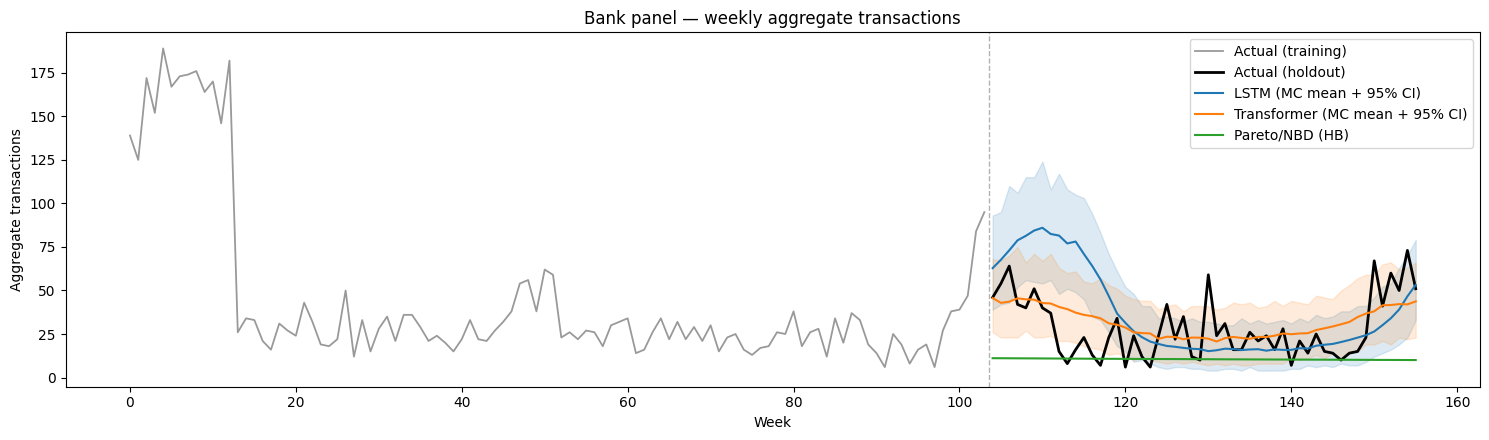

In [17]:
# Aggregate actuals across customers per holdout week.
actuals = forecast_LSTM["actual"].sum(axis=0)            # (T_HOLD,)

target_idx    = data_full["seq_cols"].index(data_full["target_col"])
train_actuals = data_full["calibration"][..., target_idx].sum(axis=0)   # (T_CAL,)

mc_sims = forecast_LSTM["simulations"][..., None]        # (S, N, T_HOLD, 1)
trf_sims = forecast_TRANSFORMER["simulations"][..., None]  # (S, N, T_HOLD, 1)

fig, ax = plot_weekly_aggregated(
				actuals=actuals,
    data=data_best,
    pareto_paper_benchmark=True,      
				predictions_by_model={"LSTM (MC mean + 95% CI)": mc_sims,
                          "Transformer (MC mean + 95% CI)": trf_sims,
},
				train_actuals=train_actuals,                    # omit to plot only the holdout
				title="Bank panel — weekly aggregate transactions",
				show_ci=True,
				# save_path="figures/bank_lstm_weekly.png",    # uncomment to save
)


In [18]:
# ---- 11. Side-by-side metrics: LSTM vs the Pareto/NBD benchmarks ---------
# metrics_table scores each model on the same holdout actuals and returns a
# tidy DataFrame (one row per model, columns = RMSE / bias% / MAPE).
#   - forecast["simulations"][..., None]: the (S, N, T_HOLD, 1) shape tells the
#     aggregator this is a Monte Carlo array (it averages the paths internally).
#   - pareto_*_benchmark=True: fit and score the two Pareto/NBD comparators
#     (MLE "lifetimes" + hierarchical-Bayes) on the SAME cohort.
#   - data=data_best: the benchmarks read train_panel / T_HOLD / ids / etc.
#     from it, so they are fit on exactly the customers the LSTM forecast.
tbl = metrics_table(
    forecast_LSTM["actual"],
    {
        "LSTM": forecast_LSTM["simulations"][..., None],
        "Transformer": forecast_TRANSFORMER["simulations"][..., None],
    },
    pareto_nbd_benchmark=True,
    pareto_paper_benchmark=True,
    data=data_best,
)
print(tbl)

/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


                     rmse  bias_percent  mape_aggregate_style
model                                                        
LSTM             0.377452     30.789025             68.775392
Transformer      0.376392     12.632584             43.184049
Pareto/NBD       0.375494    -60.065550             63.846879
Pareto/NBD (HB)  0.375823    -62.641629             65.379948


In [19]:
# ---- 12. Aggregate-total sanity check -----------------------------------
# Compare the TOTAL transactions over the whole holdout (summed across all
# customers and weeks) for each model against the truth. A fast gut-check on
# overall level/bias that complements the per-week metrics above.
# _pareto_from_data is the internal benchmark fitter metrics_table uses; we call
# it directly here just to get each Pareto variant's total.
import numpy as np
from panelclv.evaluation.plot_utils import _pareto_from_data
A   = forecast_LSTM["actual"].sum()                          # total actual holdout tx
L   = forecast_LSTM["simulations"].mean(0).sum()             # LSTM total (mean over paths)
TR  = forecast_TRANSFORMER["simulations"].mean(0).sum()      # Transformer total (mean over paths)
P   = _pareto_from_data(data_best, "mle").sum()              # Pareto MLE total
H   = _pareto_from_data(data_best, "paper").sum()            # Pareto HB total
print(f"actual={A:.0f}  LSTM={L:.0f}  Transformer={TR:.0f}  Pareto={P:.0f}  HB={H:.0f}")
# Context: average transactions per week in each window. NOTE [...,0] is the
# target channel only because Transactions is seq_cols[0] here (target_idx==0);
# use data_best['target_idx'] if you ever reorder the schema.
print(f"calib total/wk={data_best['calibration'][...,0].sum()/data_best['calibration'].shape[1]:.0f}  "
      f"holdout total/wk={A/forecast_LSTM['actual'].shape[1]:.0f}")


/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


actual=1467  LSTM=1919  Transformer=1652  Pareto=661  HB=548
calib total/wk=45  holdout total/wk=28


## Comparaison by groups

In [20]:
from panelclv.evaluation import (
    assign_customer_groups,   # Function 1: data -> {group: ids}

    group_metrics_table,      # convenience: loops F2 over {group: ids} + saves CSV

)

In [21]:
group_ids = assign_customer_groups(data_best, groups=("At Risk", "Opportunity"))

In [22]:
model_preds = {
    "LSTM":            "FOR_ANALYSIS/lstm_cross_entropy_cfg_2yTrain_1yPred_NoCov_n200_seed42_20260621_162913/predictions.csv",
    "Transformer":     "FOR_ANALYSIS/transformer_cross_entropy_cfg_2yTrain_1yPred_NoCov_n200_seed42_20260621_164423/predictions.csv",
    "Pareto/NBD (HB)": "FOR_ANALYSIS/pareto_hb_cfg_2yTrain_1yPred_NoCov_20260621_170730/predictions.csv",
}
# 3) one table, per (group, model), saved to CSV
table = group_metrics_table(data_full, model_preds, group_ids,
                            save_path="FOR_ANALYSIS/metrics_by_group.csv")
print(table)

                             n_customers      rmse       mape  bias_percent
group       model                                                          
At Risk     LSTM                     140  0.061453        NaN           NaN
            Pareto/NBD (HB)          140  0.020428        NaN           NaN
            Transformer              140  0.051800        NaN           NaN
Opportunity LSTM                      81  0.898011  75.401800    -63.824059
            Pareto/NBD (HB)           81  0.903585  95.220916    -93.753761
            Transformer               81  0.899009  79.232406    -72.142390


In [23]:
model_preds = {
    "LSTM":            "FOR_ANALYSIS/lstm_cross_entropy_cfg_2yTrain_1yPred_NoCov_n200_seed42_20260621_214318/predictions.csv",
    "Transformer":     "FOR_ANALYSIS/transformer_cross_entropy_cfg_2yTrain_1yPred_NoCov_n200_seed42_20260621_214820/predictions.csv",
    "Pareto/NBD (HB)": "FOR_ANALYSIS/pareto_hb_cfg_2yTrain_1yPred_NoCov_20260621_214840/predictions.csv",
}
# 3) one table, per (group, model), saved to CSV
table = group_metrics_table(data_full, model_preds, group_ids,
                            save_path="FOR_ANALYSIS/metrics_by_group_2.csv")
print(table)

                             n_customers      rmse       mape  bias_percent
group       model                                                          
At Risk     LSTM                     140  0.042927        NaN           NaN
            Pareto/NBD (HB)          140  0.020428        NaN           NaN
            Transformer              140  0.045379        NaN           NaN
Opportunity LSTM                      81  0.900136  81.481997    -75.306874
            Pareto/NBD (HB)           81  0.903585  95.220916    -93.753761
            Transformer               81  0.899686  81.013912    -74.572013


In [24]:
model_preds = {
    "LSTM":            "FOR_ANALYSIS/lstm_cross_entropy_cfg_2yTrain_1yPred_NoCov_n200_seed42_20260621_221024/predictions.csv",
    "Transformer":     "FOR_ANALYSIS/transformer_cross_entropy_cfg_2yTrain_1yPred_NoCov_n200_seed42_20260621_222444/predictions.csv",
    "Pareto/NBD (HB)": "FOR_ANALYSIS/pareto_hb_cfg_2yTrain_1yPred_NoCov_20260621_222504/predictions.csv",
}
# 3) one table, per (group, model), saved to CSV
table = group_metrics_table(data_full, model_preds, group_ids,
                            save_path="FOR_ANALYSIS/metrics_by_group_2.csv")
print(table)

                             n_customers      rmse       mape  bias_percent
group       model                                                          
At Risk     LSTM                     140  0.059670        NaN           NaN
            Pareto/NBD (HB)          140  0.020428        NaN           NaN
            Transformer              140  0.046968        NaN           NaN
Opportunity LSTM                      81  0.898607  79.358429    -69.435352
            Pareto/NBD (HB)           81  0.903585  95.220916    -93.753761
            Transformer               81  0.899249  80.519640    -74.069558
